# 04 — Eye Disease CNN Classification: VitalsAI

This notebook trains a **MobileNetV2 Transfer Learning CNN** on the Eye Disease dataset to classify 5 eye conditions from fundus images.

**Classes:** Bulging Eyes | Cataracts | Crossed Eyes | Glaucoma | Uveitis

**Key steps:**
- Dataset loading from Kaggle
- Data Augmentation (rotation, zoom, flip, brightness)
- MobileNetV2 Transfer Learning
- Phase 1: Frozen base — train classifier head
- Phase 2: Fine-tuning top 30 layers
- Model saving for VitalsAI deployment

⚡ **Runtime > Change runtime type > T4 GPU** set karo pehla!

## 1. GPU Check

In [6]:
# ── CELL 1: GPU Check ─────────────────────────────────────
import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('✅ GPU ready!' if tf.config.list_physical_devices('GPU') else '⚠️ GPU nathi — Runtime > T4 GPU set karo!')

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU ready!


In [7]:
import tensorflow as tf
print(tf.__version__)


2.19.0


## 2. Load Dataset from Kaggle
Downloading Eye Disease dataset using Kaggle API.

**Dataset:** kondwani/eye-disease-dataset
**Total images:** 383 across 5 classes

In [8]:
# ── CELL 3: Kaggle credentials set karo ───────────────────
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kondwani/eye-disease-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eye-disease-dataset' dataset.
Path to dataset files: /kaggle/input/eye-disease-dataset


### Option B: Manual Upload (if no Kaggle API)

In [9]:
# ── CELL 4 (Optional): Manual ZIP upload ──────────────────
# Only run karo jyo Kaggle API na hoy
# from google.colab import files
# uploaded = files.upload()   # Eye_diseases.zip upload karo
# import zipfile
# with zipfile.ZipFile('Eye_diseases.zip', 'r') as z:
#     z.extractall('/content/')
# print('✅ Extracted!')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Dataset Verification
Verifying folder structure and image counts per class.

In [10]:
# ── CELL 5: Dataset Verify ────────────────────────────────
import os

DATASET_DIR = '/content/drive/MyDrive/eye disease dl/Eye_diseases'
classes = sorted([d for d in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, d))])
total = 0
print('📁 Dataset:')
for c in classes:
    n = len(os.listdir(os.path.join(DATASET_DIR, c)))
    total += n
    print(f'   {c:20s}: {n} images')
print(f'   {"TOTAL":20s}: {total} images')
print(f'\n✅ {len(classes)} classes found: {classes}')

📁 Dataset:
   Bulging_Eyes        : 30 images
   Cataracts           : 47 images
   Crossed_Eyes        : 174 images
   Eye_diseases        : 5 images
   Glaucoma            : 82 images
   Uveitis             : 50 images
   TOTAL               : 388 images

✅ 6 classes found: ['Bulging_Eyes', 'Cataracts', 'Crossed_Eyes', 'Eye_diseases', 'Glaucoma', 'Uveitis']


## 4. Imports & Config
Setting image size (150×150), batch size, and random seed for reproducibility.

In [11]:
# ── CELL 6: Imports & Config ──────────────────────────────
import numpy as np
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# CONFIG — app.py saathe exact match
IMG_SIZE   = (150, 150)
BATCH_SIZE = 16
SEED       = 42
MODELS_DIR = '/content/models'

os.makedirs(MODELS_DIR, exist_ok=True)
tf.random.set_seed(SEED)
np.random.seed(SEED)
print('✅ Config ready — IMG_SIZE:', IMG_SIZE)

✅ Config ready — IMG_SIZE: (150, 150)


## 5. Data Augmentation & Generators
Applying augmentation to handle small dataset:
- Rotation ±20°
- Width/height shift 15%
- Zoom 20%
- Horizontal flip
- Brightness range 0.8–1.2
- 80% train / 20% validation split

In [12]:
# ── CELL 7: Data Generators ───────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', shuffle=True, seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    DATASET_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', shuffle=False, seed=SEED
)

NUM_CLASSES = len(train_gen.class_indices)
print('\nClass indices:', train_gen.class_indices)
print(f'Train: {train_gen.samples} | Val: {val_gen.samples}')

# Save class_indices.json
ci_path = os.path.join(MODELS_DIR, 'eye_class_indices.json')
with open(ci_path, 'w') as f:
    json.dump(train_gen.class_indices, f, indent=2)
print(f'\n💾 Saved: {ci_path}')

Found 615 images belonging to 6 classes.
Found 151 images belonging to 6 classes.

Class indices: {'Bulging_Eyes': 0, 'Cataracts': 1, 'Crossed_Eyes': 2, 'Eye_diseases': 3, 'Glaucoma': 4, 'Uveitis': 5}
Train: 615 | Val: 151

💾 Saved: /content/models/eye_class_indices.json


## 6. Class Weights
Computing class weights to handle imbalanced class distribution (e.g., Crossed Eyes: 174 vs Bulging Eyes: 30).

In [13]:
# ── CELL 8: Class Weights ─────────────────────────────────
labels = train_gen.classes
cw = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(cw))
rev = {v: k for k, v in train_gen.class_indices.items()}
print('⚖️ Class weights:')
for idx, w in class_weights.items():
    print(f'   {rev[idx]:20s}: {w:.3f}')

⚖️ Class weights:
   Bulging_Eyes        : 4.271
   Cataracts           : 2.697
   Crossed_Eyes        : 0.732
   Eye_diseases        : 0.334
   Glaucoma            : 1.553
   Uveitis             : 2.562


## 7. Build MobileNetV2 Model
Architecture: MobileNetV2 (ImageNet weights) → GlobalAveragePooling → Dense(256) → Dropout(0.5) → Dense(128) → Dropout(0.3) → Dense(5, softmax)

In [14]:
# ── CELL 9: Build MobileNetV2 Model ──────────────────────
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f'✅ Model built | Params: {model.count_params():,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model built | Params: 2,624,710


## 8. Phase 1 — Train Classifier Head (Base Frozen)
Freezing MobileNetV2 base layers and training only the classifier head.

- Optimizer: Adam(lr=1e-3)
- Epochs: 25
- EarlyStopping patience: 10

In [15]:
# ── CELL 10: PHASE 1 — Train Classifier Head ─────────────
print('='*55)
print('PHASE 1: Training classifier (base frozen)')
print('='*55)

checkpoint_path = os.path.join(MODELS_DIR, 'eye_cnn_best.h5')
steps = max(1, train_gen.samples // BATCH_SIZE)
vsteps = max(1, val_gen.samples // BATCH_SIZE)

cb1 = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

h1 = model.fit(
    train_gen, steps_per_epoch=steps,
    validation_data=val_gen, validation_steps=vsteps,
    epochs=25, callbacks=cb1,
    class_weight=class_weights, verbose=1
)
print(f'\n✅ Phase 1 best val_acc: {max(h1.history["val_accuracy"]):.4f}')

PHASE 1: Training classifier (base frozen)
Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2553 - loss: 2.4358
Epoch 1: val_accuracy improved from None to 0.20139, saving model to /content/models/eye_cnn_best.h5



Epoch 1: finished saving model to /content/models/eye_cnn_best.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 230s 6s/step - accuracy: 0.2387 - loss: 2.3541 - val_accuracy: 0.2014 - val_loss: 1.9082 - learning_rate: 0.0010
Epoch 2/25
 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0625 - loss: 1.8581
Epoch 2: val_accuracy did not improve from 0.20139
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.0625 - loss: 1.8581 - val_accuracy: 0.1944 - val_loss: 1.8993 - learning_rate: 0.0010
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.2614 - loss: 2.0171
Epoch 3: val_accuracy did not improve from 0.20139
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.2671 - loss: 1.9080 - val_accuracy: 0.2014 - val_loss: 2.1257 - learning_rate: 0.0010
Epoch 4/25
 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2500 - loss: 2.8097
Epoch 4: val_accuracy did not improve from 0.20139
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2500 - loss: 2.8097 - val_accuracy: 0.2014 - val_


Epoch 5: finished saving model to /content/models/eye_cnn_best.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - accuracy: 0.3105 - loss: 1.5304 - val_accuracy: 0.2292 - val_loss: 1.9159 - learning_rate: 0.0010
Epoch 6/25
 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3125 - loss: 1.5854
Epoch 6: val_accuracy did not improve from 0.22917
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3125 - loss: 1.5854 - val_accuracy: 0.2222 - val_loss: 1.9034 - learning_rate: 0.0010
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.2401 - loss: 1.6069
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_accuracy improved from 0.22917 to 0.25694, saving model to /content/models/eye_cnn_best.h5



Epoch 7: finished saving model to /content/models/eye_cnn_best.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 280ms/step - accuracy: 0.2838 - loss: 1.4926 - val_accuracy: 0.2569 - val_loss: 2.2389 - learning_rate: 0.0010
Epoch 8/25
 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1875 - loss: 1.5459
Epoch 8: val_accuracy improved from 0.25694 to 0.26389, saving model to /content/models/eye_cnn_best.h5



Epoch 8: finished saving model to /content/models/eye_cnn_best.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1875 - loss: 1.5459 - val_accuracy: 0.2639 - val_loss: 2.2369 - learning_rate: 5.0000e-04
Epoch 9/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.3124 - loss: 1.3631
Epoch 9: val_accuracy did not improve from 0.26389
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.3255 - loss: 1.3582 - val_accuracy: 0.2083 - val_loss: 2.2790 - learning_rate: 5.0000e-04
Epoch 10/25
 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2500 - loss: 1.5150
Epoch 10: val_accuracy did not improve from 0.26389
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2500 - loss: 1.5150 - val_accuracy: 0.2083 - val_loss: 2.2770 - learning_rate: 5.0000e-04
Epoch 11/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.3312 - loss: 1.3060
Epoch 11: val_accuracy did not improve from 0.26389
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 267ms/step - accuracy: 0.3456 - loss: 1.2760 - val_accu

## 9. Phase 2 — Fine-Tuning (Top 30 Layers Unfrozen)
Unfreezing top 30 layers of MobileNetV2 for domain adaptation.

- Optimizer: Adam(lr=1e-5) — very low LR
- Epochs: 50
- EarlyStopping patience: 12

In [16]:
# ── CELL 11: PHASE 2 — Fine-Tuning ───────────────────────
print('='*55)
print('PHASE 2: Fine-tuning top MobileNetV2 layers')
print('='*55)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train_gen.reset()
val_gen.reset()

cb2 = [
    EarlyStopping(monitor='val_accuracy', patience=12,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

h2 = model.fit(
    train_gen, steps_per_epoch=steps,
    validation_data=val_gen, validation_steps=vsteps,
    epochs=50, callbacks=cb2,
    class_weight=class_weights, verbose=1
)
print(f'\n✅ Phase 2 best val_acc: {max(h2.history["val_accuracy"]):.4f}')

PHASE 2: Fine-tuning top MobileNetV2 layers
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.3089 - loss: 1.4878
Epoch 1: val_accuracy improved from None to 0.25694, saving model to /content/models/eye_cnn_best.h5



Epoch 1: finished saving model to /content/models/eye_cnn_best.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 579ms/step - accuracy: 0.3105 - loss: 1.4724 - val_accuracy: 0.2569 - val_loss: 2.3809 - learning_rate: 1.0000e-05
Epoch 2/50
 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3125 - loss: 1.3606
Epoch 2: val_accuracy did not improve from 0.25694
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3125 - loss: 1.3606 - val_accuracy: 0.2569 - val_loss: 2.3840 - learning_rate: 1.0000e-05
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.2866 - loss: 1.5395
Epoch 3: val_accuracy did not improve from 0.25694
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.2955 - loss: 1.4516 - val_accuracy: 0.2361 - val_loss: 2.5250 - learning_rate: 1.0000e-05
Epoch 4/50
 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3750 - loss: 0.9387
Epoch 4: val_accuracy did not improve from 0.25694
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3750 - loss: 0.9387 - val_accuracy:

## 10. Final Evaluation
Evaluating model on validation set — per-class accuracy breakdown.

In [17]:
# ── CELL 12: Final Evaluation ─────────────────────────────
val_gen.reset()
loss, acc = model.evaluate(val_gen, verbose=1)
print(f'\n📊 Final Accuracy : {acc*100:.2f}%')
print(f'   Final Loss     : {loss:.4f}')

# Per-class accuracy
val_gen.reset()
y_pred = np.argmax(model.predict(val_gen, verbose=0), axis=1)
y_true = val_gen.classes[:len(y_pred)]
correct = Counter()
total_c = Counter()
for t, p in zip(y_true, y_pred):
    total_c[rev[t]] += 1
    if t == p:
        correct[rev[t]] += 1
print('\n📋 Per-class accuracy:')
for cls in sorted(train_gen.class_indices.keys()):
    tot = total_c.get(cls, 0)
    cor = correct.get(cls, 0)
    print(f'   {cls:20s}: {cor}/{tot}  ({cor/tot*100:.1f}%)' if tot else f'   {cls}: 0 samples')

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 406ms/step - accuracy: 0.2781 - loss: 2.3146

📊 Final Accuracy : 27.81%
   Final Loss     : 2.3146

📋 Per-class accuracy:
   Bulging_Eyes        : 4/6  (66.7%)
   Cataracts           : 5/9  (55.6%)
   Crossed_Eyes        : 13/34  (38.2%)
   Eye_diseases        : 3/76  (3.9%)
   Glaucoma            : 9/16  (56.2%)
   Uveitis             : 8/10  (80.0%)


## 11. Training History Plot
Visualizing Accuracy and Loss curves across Phase 1 and Phase 2 training.

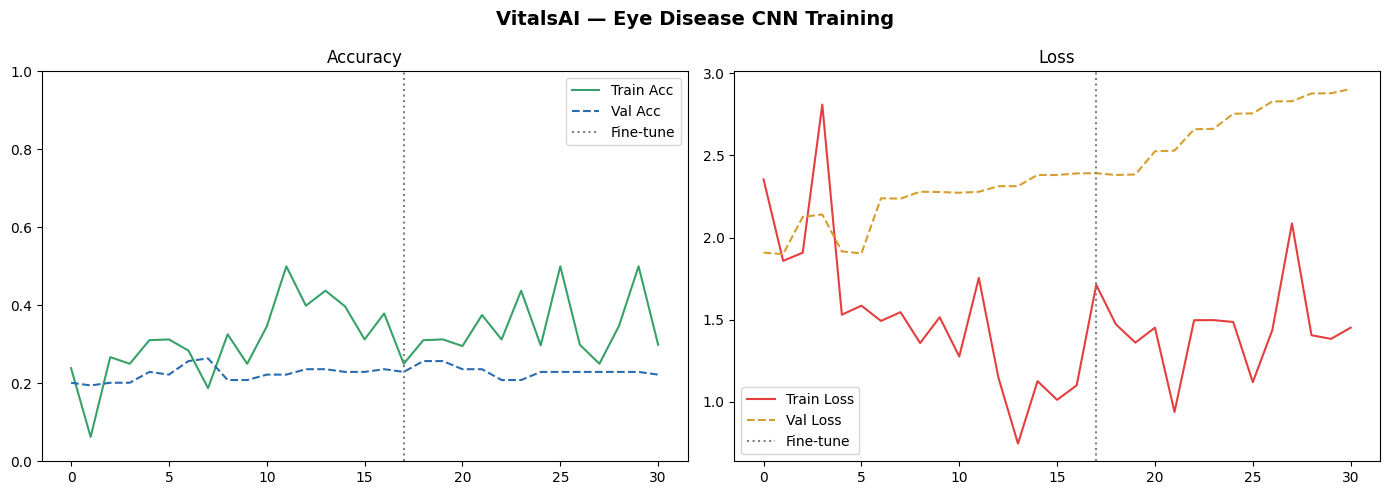

✅ Plot saved!


In [18]:
# ── CELL 13: Training Plot ────────────────────────────────
all_acc  = h1.history['accuracy']     + h2.history['accuracy']
all_vacc = h1.history['val_accuracy'] + h2.history['val_accuracy']
all_loss = h1.history['loss']         + h2.history['loss']
all_vloss= h1.history['val_loss']     + h2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VitalsAI — Eye Disease CNN Training', fontsize=14, fontweight='bold')

axes[0].plot(all_acc,  label='Train Acc',  color='#38a169')
axes[0].plot(all_vacc, label='Val Acc',    color='#2b6cb0', ls='--')
axes[0].axvline(x=len(h1.history['accuracy'])-1, color='gray', ls=':', label='Fine-tune')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].set_ylim(0,1)

axes[1].plot(all_loss,  label='Train Loss', color='#e53e3e')
axes[1].plot(all_vloss, label='Val Loss',   color='#d69e2e', ls='--')
axes[1].axvline(x=len(h1.history['loss'])-1, color='gray', ls=':', label='Fine-tune')
axes[1].set_title('Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'eye_training_plot.png'), dpi=120)
plt.show()
print('✅ Plot saved!')

## 12. Save Model for VitalsAI Deployment
Saving:
- `eye_cnn_model.h5` — TensorFlow model
- `eye_class_indices.json` — class label mapping

In [19]:
# ── CELL 14: Save Final Model ─────────────────────────────
model_path = os.path.join(MODELS_DIR, 'eye_cnn_model.h5')
model.save(model_path)
print(f'✅ Model saved: {model_path}')
print(f'✅ JSON saved : {ci_path}')

# File sizes
size_mb = os.path.getsize(model_path) / (1024*1024)
print(f'\n📦 Model size: {size_mb:.1f} MB')

✅ Model saved: /content/models/eye_cnn_model.h5
✅ JSON saved : /content/models/eye_class_indices.json

📦 Model size: 24.8 MB


## 13. Download Files to Local Machine
Downloading trained model files to integrate with VitalsAI Flask app.

In [20]:
# ── CELL 15: Download Files to Local Machine ──────────────
from google.colab import files

print('📥 Downloading eye_cnn_model.h5 ...')
files.download(model_path)

print('📥 Downloading eye_class_indices.json ...')
files.download(ci_path)

print('\n✅ Download complete!')
print('\nHave tara VS Code project ma:')
print('   models/eye_cnn_model.h5           ← move karo')
print('   models/eye_class_indices.json     ← move karo')
print('\nPachi: python app.py')
print('Eye page: http://localhost:5000/eye')

📥 Downloading eye_cnn_model.h5 ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloading eye_class_indices.json ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download complete!

Have tara VS Code project ma:
   models/eye_cnn_model.h5           ← move karo
   models/eye_class_indices.json     ← move karo

Pachi: python app.py
Eye page: http://localhost:5000/eye


## ✅ VS Code Integration Steps

Colab thi download thaya pachi:

```
vitalsai/
├── app.py
└── models/
    ├── eye_cnn_model.h5           ← move karo
    └── eye_class_indices.json     ← move karo
```

```bash
python app.py
# Open: http://localhost:5000/eye
```